In [6]:
cd C:\Users\xxxx\Documents\Power BI Desktop\data\Police_Project

C:\Users\xxxx\Documents\Power BI Desktop\data\Police_Project


In [ ]:
import numpy as np, pandas as pd
file="offence_police_district_08485.xlsx"
raw=pd.read_excel(file, sheet_name="AnmeldteLovbrudd", header=None)
raw.shape
raw.head(43)
df=raw.iloc[3:43, :13]
df.columns=(["Measure", "Region", "OffenceGroup"] + list(range(2016,2026)))
df.head(43)
df.Measure=df["Measure"].ffill()
df.Region=df.Region.ffill()
df.OffenceGroup=df.OffenceGroup.str.replace("¬", "")
df.OffenceGroup=df.OffenceGroup.str.replace(r" ", "")
df.OffenceGroup.unique()
df.head(10)
crime_df=df.melt(id_vars=["Measure", "Region", "OffenceGroup"], var_name="Year", value_name="Value")
crime_df.head(43)
crime_df.shape
crime_df.Year=crime_df.Year.astype(int)
crime_df.Value=pd.to_numeric(crime_df.Value, errors="coerce") 
crime_df=crime_df.sort_values(["Measure", "Region", "OffenceGroup", "Year"]).reset_index(drop=True) 
crime_df.head(10)
print(crime_df.dtypes) 
print(crime_df.isnull().sum())
print(crime_df.duplicated().sum())
save_file="crime_df.csv"

In [62]:
output_file=Path("offence_police_district_08485.csv")
clean_crime_df=crime_df.rename(columns={"Measure": "measure", "Region": "region", "OffenceGroup": "offencegroup", "Year":"year", "Value":"value"})
mapp={"Offences reported": "offence_count", "Offences reported per 1000 population": "rate_per_1000"}
clean_crime_df["measurecode"]=clean_crime_df["measure"].map(mapp) 
from pathlib import Path 
clean_crime_df.to_csv(output_file, index=False, encoding="utf-8")
print("save to")
print(output_file.resolve())
display(clean_crime_df)


save to
C:\Users\xxxx\Documents\Power BI Desktop\data\Police_Project\offence_police_district_08485.csv


,measure,region,offencegroup,year,value,measurecode
0,Offences reported,Total,Allgroupsofoffences,2016,336413.0,offence_count
1,Offences reported,Total,Allgroupsofoffences,2017,318617.0,offence_count
2,Offences reported,Total,Allgroupsofoffences,2018,317927.0,offence_count
3,Offences reported,Total,Allgroupsofoffences,2019,310120.0,offence_count
4,Offences reported,Total,Allgroupsofoffences,2020,300636.0,offence_count
...,...,...,...,...,...,...
395,Offences reported per 1000 population,Trøndelag,Violenceandmaltreatment,2021,5.9,rate_per_1000
396,Offences reported per 1000 population,Trøndelag,Violenceandmaltreatment,2022,6.3,rate_per_1000
397,Offences reported per 1000 population,Trøndelag,Violenceandmaltreatment,2023,6.3,rate_per_1000
398,Offences reported per 1000 population,Trøndelag,Violenceandmaltreatment,2024,7.2,rate_per_1000


In [97]:
import sqlite3
connection=sqlite3.connect("police_crime.db") 
clean_crime_df.to_sql("offence_statistics", connection, if_exists="replace", index=False)
query1 = """ 
select * from offence_statistics limit 10
"""
pd.read_sql(query1, connection)

clean_crime_df.to_sql("offence_statistics", connection, if_exists="replace", index=False)
query2="""
select year, value from offence_statistics where measurecode='offence_count' and region='Trøndelag' and offencegroup='Allgroupsofoffences' """
pd.read_sql(query2, connection)

,year,value
0,2016,24295.0
1,2017,24597.0
2,2018,23582.0
3,2019,23181.0
4,2020,23397.0
5,2021,23221.0
6,2022,24690.0
7,2023,25764.0
8,2024,28204.0
9,2025,27709.0


In [ ]:
print("region:")
for x in clean_crime_df.region.drop_duplicates():
    print(repr(x)) 

print("`\nmeasure:")
for x in clean_crime_df.measurecode.drop_duplicates():
    print(repr(x))

print("\noffencegroup:") 
for x in clean_crime_df.offencegroup.drop_duplicates():
    print(repr(x)) 

In [ ]:
output_file=Path("offence_police_district_08485.csv")
clean_crime_df=crime_df.rename(columns={"Measure": "measure", "Region": "region", "OffenceGroup": "offencegroup", "Year":"year", "Value":"value"})
mapp={"Offences reported": "offence_count", "Offences reported per 1000 population": "rate_per_1000"}
clean_crime_df["measurecode"]=clean_crime_df["measure"].map(mapp) 
from pathlib import Path 
clean_crime_df.to_csv(output_file, index=False, encoding="utf-8")
print("save to")
print(output_file.resolve())
display(clean_crime_df)

In [ ]:
crime_df.iloc[200:400,:]
{"Offences reported", "offence_count", "Offences reported per 1000 population", "rate_per_1000"}

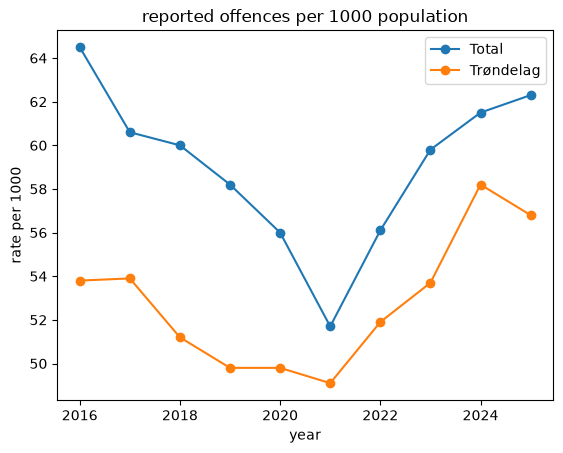

In [122]:
import sqlite3
from tokenize import group 
connection=sqlite3.connect("police_crime.db") 
clean_crime_df.to_sql("offence_statistics", connection, if_exists="replace", index=False)
query3="""
select 
year, region, value as rate_per_1000 from offence_statistics where region in ('Trøndelag', 'Total') and measurecode='rate_per_1000' and offencegroup='Allgroupsofoffences' order by year, region """
trend_df=pd.read_sql(query3, connection) 
trend_df

import matplotlib.pyplot as plt 
for region_name, group in trend_df.groupby("region"):
    plt.plot(group.year, group.rate_per_1000, marker="o", label=region_name)
    plt.title("reported offences per 1000 population")
    plt.xlabel("year")
    plt.ylabel("rate per 1000")
    plt.legend()
    plt.grid(False)

In [ ]:
output_file=Path("offence_police_district_08485.csv")
clean_crime_df=crime_df.rename(columns={"Measure": "measure", "Region": "region", "OffenceGroup": "offencegroup", "Year":"year", "Value":"value"})
mapp={"Offences reported": "offence_count", "Offences reported per 1000 population": "rate_per_1000"}
clean_crime_df["measurecode"]=clean_crime_df["measure"].map(mapp) 
from pathlib import Path 
clean_crime_df.to_csv(output_file, index=False, encoding="utf-8")
print("save to")
print(output_file.resolve())
display(clean_crime_df)


In [93]:
clean_crime_df.head(100)
connection=sqlite3.connect("police_crime.db")
tables=pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", connection)
display(tables)

,name
0,offence_statistics
